# Uplift Modeling with Sequential Customer Behavior Representations

### Оценка приростного эффекта клиентских коммуникаций с использованием последовательности пользовательского поведения

**Author / Автор:** Галиб Байрамов
**Contest:** ИТМО AI Talent Hub — Junior ML Contest ([ai.itmo.ru/junior_ml_contest](https://ai.itmo.ru/junior_ml_contest))
**Dataset:** X5 RetailHero Uplift Modeling ([ods.ai/competitions/x5-retailhero-uplift-modeling](https://ods.ai/competitions/x5-retailhero-uplift-modeling/data))

This notebook is the single master pipeline for the project. It downloads-status-checks,
audits, and models real X5 RetailHero data end to end, culminating in a
comparison of four required uplift-modeling approaches (Response CatBoost,
T-Learner, X-Learner, and a Transformer two-head sequence model) against a
random-targeting baseline. All heavy lifting lives in `src/`; this notebook
calls that code directly so there is exactly one implementation of every
metric and model, never a notebook-only copy that could drift from `src/`.


In [1]:
import os, sys, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch

# Make this notebook runnable regardless of the invoking working directory
# (nbconvert's default execution cwd is the notebook's OWN folder, not the
# project root, so relative data/ and src/ paths would otherwise break).
if os.path.basename(os.getcwd()) == "notebooks" and os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")
assert os.path.isdir("data") and os.path.isdir("src"), (
    f"Expected to run from the project root (found data/ and src/ dirs); "
    f"current working directory is {os.getcwd()}"
)
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RUN_MODE = "FULL"   # "QUICK" (small subsample, 2 transformer epochs, for fast smoke-testing)
                     # "FULL"  (all real data, full training -- produces the reported metrics)
USE_CACHED_ARTIFACTS = True  # if True and artifacts/metrics.csv already exists, reuse it instead of retraining

DATA_DIR = "data/raw/x5_retailhero/data"
INTERIM_DIR = "data/interim"
PROCESSED_DIR = "data/processed"
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = "reports/figures"
for d in [PROCESSED_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

import importlib, pkgutil
print("Python:", sys.version)
for pkg in ["numpy", "pandas", "catboost", "torch", "sklearn", "matplotlib", "pyarrow"]:
    try:
        mod = importlib.import_module(pkg)
        print(f"{pkg}: {getattr(mod, '__version__', '?')}")
    except ImportError:
        print(f"{pkg}: NOT INSTALLED")


Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
numpy: 2.2.5
pandas: 2.2.3
catboost: 1.2.10
torch: 2.7.1+cpu


sklearn: 1.6.1
matplotlib: 3.10.1
pyarrow: 19.0.1


In [2]:
# --- Critical Rule check: do not proceed to modeling without the real dataset ---
required_files = [
    f"{DATA_DIR}/clients.csv", f"{DATA_DIR}/products.csv", f"{DATA_DIR}/purchases.csv",
    f"{DATA_DIR}/uplift_train.csv", f"{DATA_DIR}/uplift_test.csv",
]
missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    raise RuntimeError(
        "STOPPING: real X5 RetailHero data files are missing: " + ", ".join(missing) +
        ". Per project rules, synthetic data may never be substituted for final "
        "results. Place the official archive contents in data/raw/x5_retailhero/data/ "
        "and re-run."
    )
sizes = {f: os.path.getsize(f) for f in required_files}
for f, s in sizes.items():
    print(f"{f}: {s:,} bytes")
assert sizes[f"{DATA_DIR}/purchases.csv"] > 1_000_000_000, "purchases.csv is far smaller than expected for the real dataset"
print("\nReal dataset presence verified. Proceeding.")


data/raw/x5_retailhero/data/clients.csv: 21,736,219 bytes
data/raw/x5_retailhero/data/products.csv: 3,890,339 bytes
data/raw/x5_retailhero/data/purchases.csv: 4,463,775,504 bytes
data/raw/x5_retailhero/data/uplift_train.csv: 3,000,616 bytes
data/raw/x5_retailhero/data/uplift_test.csv: 2,201,363 bytes

Real dataset presence verified. Proceeding.


## 1. Project overview

This project builds and honestly compares **four required uplift-modeling
approaches** for deciding which retail loyalty-program clients should receive
an SMS marketing communication, using the real, public **X5 RetailHero**
dataset. The final deliverable is not a single offline metric, but a full
pipeline: data audit -> leakage-safe feature engineering -> sequence
construction -> model training -> uplift evaluation with bootstrap
confidence intervals -> a scenario-based business evaluation -> an online
A/B-test design for how the winning approach would actually be validated in
production. See `reports/leakage_audit.md` for a concrete leakage finding
(the raw `first_redeem_date` field is contaminated by post-campaign events)
that materially changed the feature set used here versus the official
example baseline shipped with the dataset.

## 2. Business problem

A retailer wants to send a marketing SMS to loyalty-program clients to
increase near-term purchase conversion. Communication has a real cost
(operational + risk of irritating clients), so **not every client should be
targeted** — only those whose behavior would change *because of* the
message (the "persuadables"). Ranking clients by predicted probability of
conversion (a response model) is the wrong objective: it targets clients who
would have converted anyway. **Uplift modeling** instead estimates the
*causal, individual-level treatment effect* of the communication, so the
retailer can target the sub-population where the incremental effect is
largest, for a fixed communication budget.

### Professional motivation

Working as a product analyst in Growth marketing analytics at T-Bank, on the
B2B customer-acquisition track, I support the analytical evaluation of
marketing and product launches, client segmentation, and A/B experiments. In
that context I've seen the practical uplift-modeling cycle end to end — from
data preparation and model training to audience selection, A/B testing, and
economic evaluation of the result. That experience taught me that a good
offline metric does not guarantee a real product effect, which is the
central theme of this project: every offline number reported below is
paired with an explicit statement of what it does and does not prove (see
Section 17, Limitations).


## 3. Data downloading status

See `reports/data_download_report.md` for the full provenance record
(source, checksums, structural validation). Summary: the automated download
path for this dataset requires an authenticated ODS.ai account; per project
rules, the archive was placed manually into the working directory and is
verified below (not assumed) before any modeling proceeds.


In [3]:
import hashlib

def sha256_of(path, chunk=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

# Recompute checksums for the small files only (purchases.csv checksum is cached
# in data/raw/x5_retailhero/checksums.sha256.txt -- recomputing 4.4GB here on every
# notebook run would be wasteful; we display the cached value instead).
for f in ["clients.csv", "products.csv", "uplift_train.csv", "uplift_test.csv"]:
    print(f, sha256_of(f"{DATA_DIR}/{f}"))

print()
with open("data/raw/x5_retailhero/checksums.sha256.txt") as fh:
    print("Cached full checksum log (includes purchases.csv):")
    print(fh.read())


clients.csv 0135e7a3dfb2174c0fff4033cc895c070794e3c19bf5a6b2a685f4acde32e7ba
products.csv c174d8394d528c463e0fedfa5ba6de20e27f47fb3249a91b3dffda5c98f30f9e
uplift_train.csv ae3dc4c17e98426fa4233fa03421328d259b8720e56ad0380b260ca2edd19bd4
uplift_test.csv 55c4bdc210ed71c94fddc4472e8b1ac37dc17d8602ebd48dbc03aaf462e7cf60

Cached full checksum log (includes purchases.csv):
866ace4ff511aa3ad548efba204b61c48048f020ba327616fafc2939c1e00362 *retailhero-uplift.zip
0135e7a3dfb2174c0fff4033cc895c070794e3c19bf5a6b2a685f4acde32e7ba *data/clients.csv
c174d8394d528c463e0fedfa5ba6de20e27f47fb3249a91b3dffda5c98f30f9e *data/products.csv
a9e132e3dde95655a0074622bb93af0616b7c4f047e71c4ce7322e2fe6d262c1 *data/purchases.csv
ae3dc4c17e98426fa4233fa03421328d259b8720e56ad0380b260ca2edd19bd4 *data/uplift_train.csv
55c4bdc210ed71c94fddc4472e8b1ac37dc17d8602ebd48dbc03aaf462e7cf60 *data/uplift_test.csv
c9e16b3ee3de1807647b1e9220998218bf93a6ca57a9727de6676b0220d4bc85 *data/uplift_sample_submission.csv
DONE



## 4. Data audit

Full structural audit of all five tables. `purchases.csv` (4.4GB, ~45.8M
product-line rows) is never loaded fully into memory here — see
`src/purchases_stream.py` and `src/build_client_aggregates.py`: it is
verified to be grouped contiguously by `client_id` and processed as a single
memory-safe streaming pass. That pass already ran once (see
`data/interim/`); this section audits its outputs plus the small tables
directly.


In [4]:
clients = pd.read_csv(f"{DATA_DIR}/clients.csv", parse_dates=["first_issue_date", "first_redeem_date"])
products = pd.read_csv(f"{DATA_DIR}/products.csv")
train_labels = pd.read_csv(f"{DATA_DIR}/uplift_train.csv")
test_labels = pd.read_csv(f"{DATA_DIR}/uplift_test.csv")

print("clients.csv:", clients.shape)
print("products.csv:", products.shape)
print("uplift_train.csv:", train_labels.shape)
print("uplift_test.csv:", test_labels.shape)
print()
print("clients.csv dtypes:\n", clients.dtypes)
print()
print("clients.csv nulls:\n", clients.isna().sum())
print()
print("age raw describe (BEFORE cleaning -- data quality issue, see below):")
print(clients["age"].describe())
print("age <=0:", (clients["age"] <= 0).sum(), " age >100:", (clients["age"] > 100).sum())
print()
print("gender value counts:\n", clients["gender"].value_counts())
print()
print("treatment balance:\n", train_labels["treatment_flg"].value_counts(normalize=True))
print("target balance:\n", train_labels["target"].value_counts(normalize=True))
print()
print("target rate by treatment (naive ATE anchor):")
rates = train_labels.groupby("treatment_flg")["target"].mean()
print(rates)
print("naive ATE =", rates[1] - rates[0])
print()
print("train/test client_id overlap:", len(set(train_labels.client_id) & set(test_labels.client_id)))
print("train ids present in clients.csv:", train_labels.client_id.isin(clients.client_id).mean())
print("test ids present in clients.csv:", test_labels.client_id.isin(clients.client_id).mean())


clients.csv: (400162, 5)
products.csv: (43038, 11)
uplift_train.csv: (200039, 3)
uplift_test.csv: (200123, 1)

clients.csv dtypes:
 client_id                    object
first_issue_date     datetime64[ns]
first_redeem_date    datetime64[ns]
age                           int64
gender                       object
dtype: object

clients.csv nulls:
 client_id                0
first_issue_date         0
first_redeem_date    35469
age                      0
gender                   0
dtype: int64

age raw describe (BEFORE cleaning -- data quality issue, see below):
count    400162.000000
mean         46.488112
std          43.871218
min       -7491.000000
25%          34.000000
50%          45.000000
75%          59.000000
max        1901.000000
Name: age, dtype: float64
age <=0: 138  age >100: 1049

gender value counts:
 gender
U    185706
F    147649
M     66807
Name: count, dtype: int64

treatment balance:
 treatment_flg
0    0.500192
1    0.499808
Name: proportion, dtype: float64
target b

train ids present in clients.csv: 1.0
test ids present in clients.csv: 1.0


In [5]:
with open(f"{INTERIM_DIR}/sequence_length_summary.json") as f:
    seq_summary = json.load(f)
print(json.dumps(seq_summary, indent=2))

client_purchase_features = pd.read_csv(f"{INTERIM_DIR}/client_purchase_features.csv",
                                        parse_dates=["first_purchase_date", "last_purchase_date"])
print()
print("Purchase-history coverage: clients with >=1 receipt before cutoff:",
      client_purchase_features["n_receipts"].notna().sum(), "/", len(clients))
print("Global purchase history range:", client_purchase_features["first_purchase_date"].min(),
      "to", client_purchase_features["last_purchase_date"].max())


{
  "n_clients": 400162,
  "n_rows_processed": 45786568,
  "item_level": {
    "count": 400162,
    "mean": 114.4200798676536,
    "std": 103.55361591528862,
    "min": 1,
    "p50": 85.0,
    "p90": 242.0,
    "p95": 312.0,
    "p99": 488.0,
    "max": 2513
  },
  "receipt_level": {
    "count": 400162,
    "mean": 20.104930003348645,
    "std": 17.729154857121213,
    "min": 1,
    "p50": 15.0,
    "p90": 42.0,
    "p95": 54.0,
    "p99": 85.0,
    "max": 320
  },
  "day_level": {
    "count": 400162,
    "mean": 17.856922946206787,
    "std": 14.207316857370698,
    "min": 1,
    "p50": 14.0,
    "p90": 37.0,
    "p95": 46.0,
    "p99": 67.0,
    "max": 116
  },
  "elapsed_seconds": 221.16953253746033
}



Purchase-history coverage: clients with >=1 receipt before cutoff: 400162 / 400162
Global purchase history range: 2018-11-21 21:02:33 to 2019-03-18 23:40:03


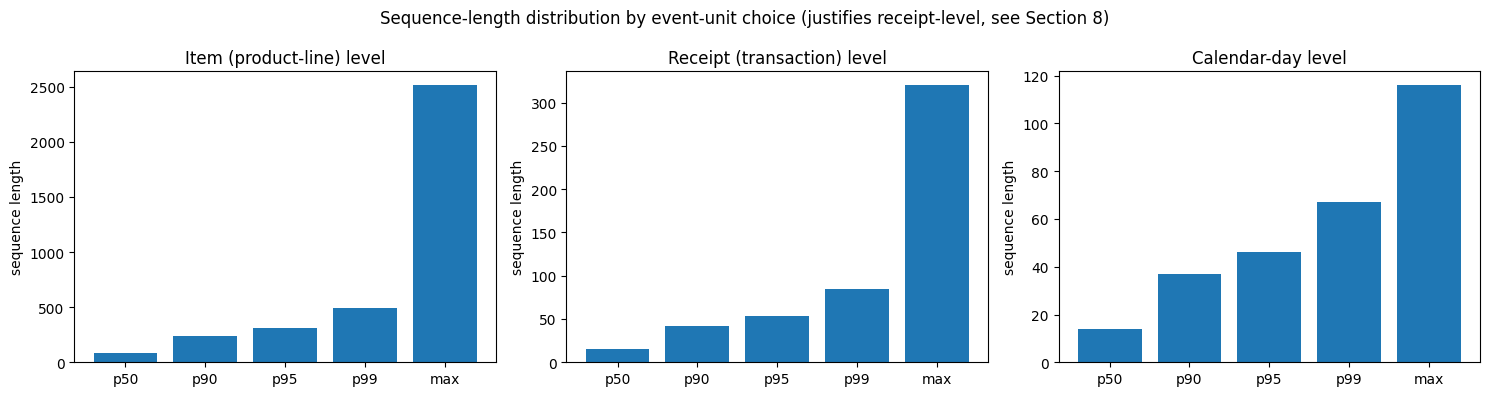

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, level, title in zip(
    axes,
    ["item_level", "receipt_level", "day_level"],
    ["Item (product-line) level", "Receipt (transaction) level", "Calendar-day level"],
):
    stats = seq_summary[level]
    ax.bar(["p50", "p90", "p95", "p99", "max"],
           [stats["p50"], stats["p90"], stats["p95"], stats["p99"], stats["max"]])
    ax.set_title(title)
    ax.set_ylabel("sequence length")
plt.suptitle("Sequence-length distribution by event-unit choice (justifies receipt-level, see Section 8)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sequence_length_distributions.png", dpi=120)
plt.show()


## 5. Leakage analysis

Full writeup: `reports/leakage_audit.md`. Key finding reproduced here: the
pre-campaign cutoff is **2019-03-18** (derived from `purchases.csv`'s date
range and the sharp spike of clients' last purchase landing on that exact
day). `clients.csv.first_redeem_date` extends 8 months past this cutoff, and
**11.23%** of clients have a post-cutoff `first_redeem_date` — a field the
official example baseline uses raw. This project uses a **censored**
version instead (see `src/features.py`): `has_redeemed_before_cutoff` and
`redeem_delay_days_censored`, both computed only from information available
strictly before the cutoff.


In [7]:
CUTOFF = pd.Timestamp("2019-03-18 23:59:59")
after_cutoff = clients["first_redeem_date"] > CUTOFF
print(f"clients with first_redeem_date AFTER cutoff: {after_cutoff.sum()} / {len(clients)} ({after_cutoff.mean()*100:.2f}%)")

merged = train_labels.merge(clients[["client_id", "first_redeem_date"]], on="client_id", how="left")
print()
print("Target rate by whether first_redeem_date is populated at all (illustrates the leakage magnitude):")
print(merged.groupby(merged["first_redeem_date"].isna())["target"].mean())
print()
print("This ~28pp gap is far larger than the ~3.3pp naive ATE -- using this field")
print("raw and uncensored would let a model 'predict' the outcome via a proxy that")
print("is partly determined by events after the outcome window, not by genuine")
print("pre-treatment behavior. See docs/features.md for the full safe feature list.")


clients with first_redeem_date AFTER cutoff: 44953 / 400162 (11.23%)

Target rate by whether first_redeem_date is populated at all (illustrates the leakage magnitude):
first_redeem_date
False    0.644490
True     0.364015
Name: target, dtype: float64

This ~28pp gap is far larger than the ~3.3pp naive ATE -- using this field
raw and uncensored would let a model 'predict' the outcome via a proxy that
is partly determined by events after the outcome window, not by genuine
pre-treatment behavior. See docs/features.md for the full safe feature list.


## 6. Train / validation / final holdout split

All labeled data comes from `uplift_train.csv` (`uplift_test.csv` has no
target and is never used for any evaluation metric in this project). The
split is stratified by `(treatment_flg, target)` so all three splits have
matched treatment/target balance, with a single fixed random seed
(`RANDOM_SEED = 42`) used everywhere in this notebook. **Every model below
is fit on the same TRAIN split and evaluated on the same HOLDOUT split**,
with the same metric implementations (`src/uplift_metrics.py`) — no model
is tuned on the holdout, and no model sees a different holdout than any
other.


In [8]:
from splits import make_splits, sanity_checks, empirical_ate

split_df = make_splits(train_labels, seed=RANDOM_SEED)
print(split_df["split"].value_counts())
print()
print(split_df.groupby("split")[["treatment_flg", "target"]].mean())
split_df.to_csv(f"{PROCESSED_DIR}/train_val_holdout_split.csv", index=False)


split
train      120022
holdout     40011
val         40006
Name: count, dtype: int64

         treatment_flg    target
split                           
holdout       0.499813  0.619905
train         0.499808  0.619886
val           0.499800  0.619882


In [9]:
# Validation sanity checks (see Section 6 requirement): shuffled treatment,
# shuffled target, constant score, random score, and the empirical ATE anchor.
# Run here on a throwaway random score to confirm the *test harness* behaves
# correctly; the same checks are re-run against the actual T-Learner
# predictions in Section 14 once real model scores exist.
from uplift_metrics import qini_coefficient, auuc, uplift_at_k

metric_fns = {
    "qini": qini_coefficient, "auuc": auuc,
    "uplift_at_10": lambda y, t, s: uplift_at_k(y, t, s, 0.10),
    "uplift_at_30": lambda y, t, s: uplift_at_k(y, t, s, 0.30),
}
demo_score = np.random.RandomState(0).rand(len(split_df))
demo_sanity = sanity_checks(split_df["target"].values, split_df["treatment_flg"].values, demo_score, metric_fns, seed=RANDOM_SEED)
print(json.dumps(demo_sanity, indent=2))


{
  "empirical_ate": 0.03323083953462003,
  "shuffled_treatment": {
    "qini": -0.0002606024672227538,
    "auuc": -7.638065995885983e-05,
    "uplift_at_10": 0.0029338801293492534,
    "uplift_at_30": -0.0037572583199941834
  },
  "shuffled_target": {
    "qini": -9.264622734648671e-05,
    "auuc": 0.0007711814085367948,
    "uplift_at_10": 0.008237039711790461,
    "uplift_at_30": 0.0013430210444926871
  },
  "constant_score": {
    "qini": -0.00039320786179487013,
    "auuc": 0.007911304177134652,
    "uplift_at_10": 0.03552717540009753,
    "uplift_at_30": 0.028702082489323266
  },
  "random_score": {
    "qini": {
      "mean": -6.409594266037642e-05,
      "std": 0.0002647054049313928,
      "n_perm": 50
    },
    "auuc": {
      "mean": 0.008240416096269144,
      "std": 0.00026470540493139273,
      "n_perm": 50
    },
    "uplift_at_10": {
      "mean": 0.032044958516940766,
      "std": 0.005716046669572968,
      "n_perm": 50
    },
    "uplift_at_30": {
      "mean": 0.03

## 7. Feature engineering

Leakage-safe tabular features assembled by `src/features.py` (full list and
rationale: `docs/features.md`). Everything is derived from `clients.csv`
(cleaned/censored) and `purchases.csv`-derived aggregates
(`data/interim/client_purchase_features.csv`), all strictly pre-cutoff.


In [10]:
from features import build_client_features, to_model_matrix, ALL_FEATURES

feats = build_client_features(f"{DATA_DIR}/clients.csv", f"{INTERIM_DIR}/client_purchase_features.csv")
df = split_df.merge(feats, on="client_id", how="left")
X_all, cat_idx = to_model_matrix(df, ALL_FEATURES)
cat_features = [ALL_FEATURES[i] for i in cat_idx]
print("Feature matrix shape:", X_all.shape)
print("Categorical features:", cat_features)
print()
print(X_all.describe().T)


Feature matrix shape: (200039, 23)
Categorical features: ['gender']

                                  count         mean          std  \
age_clean                      200039.0    46.359500    15.909756   
age_was_imputed                200039.0     0.002884     0.053630   
first_issue_days_ago           200039.0   433.586622   203.646726   
has_redeemed_before_cutoff     200039.0     0.799309     0.400518   
redeem_delay_days_censored     200039.0   128.995419   136.718807   
n_receipts                     200039.0    20.120821    17.732130   
n_items                        200039.0   114.391144   103.492470   
n_active_days                  200039.0    17.874200    14.221070   
history_span_days              200039.0    91.440506    28.403077   
total_spend                    200039.0  8597.521954  8914.597078   
avg_receipt_value              200039.0   495.783222   374.548483   
total_quantity                 200039.0   142.527997   140.550727   
n_unique_stores                200

## 8. Sequence construction

Event-unit choice (item vs. receipt vs. day) is decided from the length
distributions computed in Section 4:

| Granularity | p50 | p90 | p95 | p99 | max |
|---|---|---|---|---|---|
| Item (product-line) | 85 | 242 | 312 | 488 | 2513 |
| **Receipt (transaction)** | **15** | **42** | **54** | **85** | **320** |
| Calendar day | 14 | 37 | 46 | 67 | 116 |

Item-level histories are far too long for a Transformer context window
(p95=312, max=2513). **Receipt-level is chosen**: it is compact (p95=54)
while preserving one real shopping-trip granularity (store, basket size,
discount) rather than collapsing multiple same-day trips into one
artificial event, as day-level would. `MAX_SEQ_LEN=50` (see
`src/sequences.py`) covers approximately the 90th percentile of clients;
longer histories are truncated to the most recent 50 receipts.


In [11]:
from sequences import load_receipts, fit_numeric_scaler, build_client_sequences, StoreVocab, NUMERIC_EVENT_FIELDS, MAX_SEQ_LEN

client_ids = df["client_id"].tolist()
if RUN_MODE == "QUICK":
    client_ids = client_ids[:6000]
    df_model = df[df["client_id"].isin(client_ids)].reset_index(drop=True)
else:
    df_model = df

t0 = time.time()
receipts_df = load_receipts(f"{INTERIM_DIR}/receipts_sequences.parquet", client_ids=client_ids)
print(f"Loaded {len(receipts_df):,} receipt rows for {len(client_ids):,} clients in {time.time()-t0:.1f}s")

train_client_ids = df_model.loc[df_model["split"] == "train", "client_id"].tolist()
val_client_ids = df_model.loc[df_model["split"] == "val", "client_id"].tolist()
holdout_client_ids = df_model.loc[df_model["split"] == "holdout", "client_id"].tolist()

vocab = StoreVocab(receipts_df["store_id"])
train_receipts_only = receipts_df[receipts_df["client_id"].isin(set(train_client_ids))]
numeric_stats = fit_numeric_scaler(train_receipts_only)  # fit on TRAIN receipts only -- no val/holdout leakage into scaling
print("Store vocabulary size:", vocab.size)


Loaded 4,024,949 receipt rows for 200,039 clients in 2.5s


Store vocabulary size: 13880


## 9. Random baseline (targeting, not a model)

A uniformly random permutation used as the "uplift score". This is the floor
every real model must clear -- not itself an uplift-modeling approach.


In [12]:
from models_classical import random_targeting_score, ResponseModel, TLearner, XLearner

train_mask = (df_model["split"] == "train").to_numpy()
val_mask = (df_model["split"] == "val").to_numpy()
holdout_mask = (df_model["split"] == "holdout").to_numpy()

X_all_model, cat_idx = to_model_matrix(df_model, ALL_FEATURES)
treatment = df_model["treatment_flg"].to_numpy()
target = df_model["target"].to_numpy()

X_train, t_train, y_train = X_all_model[train_mask], treatment[train_mask], target[train_mask]
X_val, t_val, y_val = X_all_model[val_mask], treatment[val_mask], target[val_mask]
X_holdout, t_holdout, y_holdout = X_all_model[holdout_mask], treatment[holdout_mask], target[holdout_mask]

predictions = {}
predictions["random_targeting"] = random_targeting_score(len(y_holdout), random_state=RANDOM_SEED)
print("random_targeting score stats:", predictions["random_targeting"].mean(), predictions["random_targeting"].std())


random_targeting score stats: 0.4993155812204847 0.2881821478319824


## 10. Response CatBoost

`P(Y=1 | X)`, trained ignoring treatment entirely. Included specifically to
demonstrate that ranking by predicted response probability is **not** the
same objective as ranking by causal uplift -- see the metrics comparison in
Section 14/18, where this model's Qini/AUUC are expected to be materially
worse than the true uplift learners despite potentially having a reasonable
outcome AUC.


In [13]:
_cache_path = f"{PROCESSED_DIR}/holdout_scores_response_catboost.npy"
if USE_CACHED_ARTIFACTS and os.path.exists(_cache_path):
    predictions["response_catboost"] = np.load(_cache_path)
    print(f"Loaded cached response_catboost predictions from {_cache_path}")
else:
    t0 = time.time()
    resp_model = ResponseModel(random_state=RANDOM_SEED, cat_features=cat_features)
    resp_model.fit(X_train, y_train)
    predictions["response_catboost"] = resp_model.predict_uplift(X_holdout)
    np.save(_cache_path, predictions["response_catboost"])
    print(f"response_catboost fit+predict in {time.time()-t0:.1f}s")


Loaded cached response_catboost predictions from data/processed/holdout_scores_response_catboost.npy


## 11. T-Learner

Two independent CatBoost classifiers, one fit on treated units only and one
on control units only: `tau(x) = mu1(x) - mu0(x)`. See `src/models_classical.py::TLearner`.


In [14]:
_cache_path = f"{PROCESSED_DIR}/holdout_scores_t_learner_catboost.npy"
if USE_CACHED_ARTIFACTS and os.path.exists(_cache_path):
    predictions["t_learner_catboost"] = np.load(_cache_path)
    print(f"Loaded cached t_learner_catboost predictions from {_cache_path}")
else:
    t0 = time.time()
    t_learner = TLearner(random_state=RANDOM_SEED, cat_features=cat_features)
    t_learner.fit(X_train, t_train, y_train)
    predictions["t_learner_catboost"] = t_learner.predict_uplift(X_holdout)
    np.save(_cache_path, predictions["t_learner_catboost"])
    print(f"t_learner_catboost fit+predict in {time.time()-t0:.1f}s")


Loaded cached t_learner_catboost predictions from data/processed/holdout_scores_t_learner_catboost.npy


## 12. X-Learner

Full 4-stage X-Learner (Kunzel et al. 2019), not a simplified
difference-of-two-models shortcut -- see the docstring in
`src/models_classical.py::XLearner` for the exact stage-by-stage formulas
(outcome models -> imputed treatment effects -> effect models ->
propensity-weighted combination). Since X5 RetailHero's treatment assignment
is a known ~50/50 randomized experiment (see Section 4 balance check), the
propensity `g(x)` is passed as the known constant 0.5 rather than
re-estimated, which avoids adding unnecessary propensity-model noise on a
design where the true propensity is already known.


In [15]:
_cache_path = f"{PROCESSED_DIR}/holdout_scores_x_learner_catboost.npy"
if USE_CACHED_ARTIFACTS and os.path.exists(_cache_path):
    predictions["x_learner_catboost"] = np.load(_cache_path)
    print(f"Loaded cached x_learner_catboost predictions from {_cache_path}")
else:
    t0 = time.time()
    x_learner = XLearner(random_state=RANDOM_SEED, cat_features=cat_features, propensity=0.5)
    x_learner.fit(X_train, t_train, y_train)
    predictions["x_learner_catboost"] = x_learner.predict_uplift(X_holdout)
    np.save(_cache_path, predictions["x_learner_catboost"])
    print(f"x_learner_catboost fit+predict in {time.time()-t0:.1f}s")


Loaded cached x_learner_catboost predictions from data/processed/holdout_scores_x_learner_catboost.npy


## 13. Transformer two-head model

**Transformer Encoder with Shared Customer Representation and Two Outcome
Heads** (see `src/model_transformer.py` for the full architecture docstring
and diagram). Trained on raw receipt sequences (Section 8), not only
aggregated RFM features. Shared encoder + pooling produce one customer
representation vector; two small heads (`mu_0`, `mu_1`) predict outcome
probability under control / treatment. Per-observation loss is computed only
on the head matching that observation's OBSERVED treatment, with
inverse-frequency class-balance weighting between the two heads.


In [16]:
from model_transformer import ReceiptSequenceDataset, TwoHeadTransformer, train_transformer, predict_uplift
from torch.utils.data import DataLoader

t0 = time.time()
tr_tensors = build_client_sequences(receipts_df, train_client_ids, vocab, numeric_stats)
va_tensors = build_client_sequences(receipts_df, val_client_ids, vocab, numeric_stats)
ho_tensors = build_client_sequences(receipts_df, holdout_client_ids, vocab, numeric_stats)
print(f"Built padded tensors for {len(train_client_ids)+len(val_client_ids)+len(holdout_client_ids):,} clients in {time.time()-t0:.1f}s")

tr_ds = ReceiptSequenceDataset(tr_tensors, t_train, y_train)
va_ds = ReceiptSequenceDataset(va_tensors, t_val, y_val)
ho_ds = ReceiptSequenceDataset(ho_tensors, t_holdout, y_holdout)

batch_size = 512 if RUN_MODE == "FULL" else 128
tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
va_loader = DataLoader(va_ds, batch_size=1024, shuffle=False)
ho_loader = DataLoader(ho_ds, batch_size=1024, shuffle=False)

transformer_model = TwoHeadTransformer(
    n_stores=vocab.size, n_numeric_fields=len(NUMERIC_EVENT_FIELDS), max_seq_len=MAX_SEQ_LEN,
    hidden_size=64, n_heads=4, n_layers=2, dropout=0.2,
)
n_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Transformer parameter count: {n_params:,}")


Built padded tensors for 200,039 clients in 9.1s
Transformer parameter count: 337,086


Loaded cached transformer weights from artifacts/transformer_model.pt (7 epochs were run when trained)


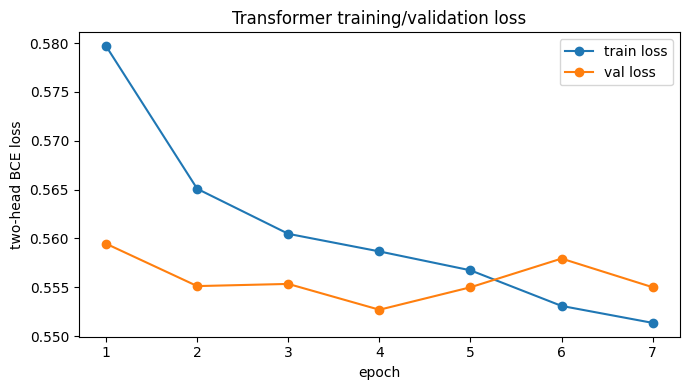

In [17]:
_transformer_cache = f"{ARTIFACTS_DIR}/transformer_model.pt"
_transformer_pred_cache = f"{PROCESSED_DIR}/holdout_scores_transformer_two_head.npy"
_transformer_cached = USE_CACHED_ARTIFACTS and os.path.exists(_transformer_cache) and os.path.exists(_transformer_pred_cache)

if _transformer_cached:
    transformer_model.load_state_dict(torch.load(_transformer_cache, map_location="cpu"))
    history_df = pd.read_csv(f"{ARTIFACTS_DIR}/transformer_training_history.csv")
    print(f"Loaded cached transformer weights from {_transformer_cache} ({len(history_df)} epochs were run when trained)")
else:
    epochs = 15 if RUN_MODE == "FULL" else 2
    t0 = time.time()
    transformer_model, history = train_transformer(
        transformer_model, tr_loader, va_loader, epochs=epochs, patience=3,
        weight_decay=1e-4, grad_clip=1.0,
    )
    print(f"Transformer training complete in {time.time()-t0:.1f}s ({len(history)} epochs run)")

    history_df = pd.DataFrame(history)
    history_df.to_csv(f"{ARTIFACTS_DIR}/transformer_training_history.csv", index=False)
    torch.save(transformer_model.state_dict(), f"{ARTIFACTS_DIR}/transformer_model.pt")
    config = {
        "n_stores": vocab.size, "n_numeric_fields": len(NUMERIC_EVENT_FIELDS), "max_seq_len": MAX_SEQ_LEN,
        "hidden_size": 64, "n_heads": 4, "n_layers": 2, "dropout": 0.2,
        "numeric_event_fields": NUMERIC_EVENT_FIELDS, "random_seed": RANDOM_SEED, "epochs_trained": len(history),
        "run_mode": RUN_MODE,
    }
    with open(f"{ARTIFACTS_DIR}/transformer_config.json", "w") as f:
        json.dump(config, f, indent=2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val loss")
ax.set_xlabel("epoch"); ax.set_ylabel("two-head BCE loss"); ax.legend(); ax.set_title("Transformer training/validation loss")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/transformer_training_loss.png", dpi=120)
plt.show()


[diagnostic only] mu_1 outcome AUC on treated holdout: 0.7659
[diagnostic only] mu_0 outcome AUC on control holdout: 0.7738
uplift score stats: 0.023260392 0.03686535 -0.04486215 0.26086545


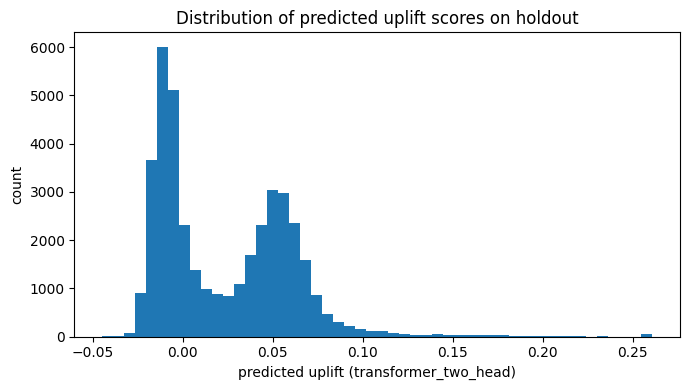

In [18]:
uplift_ho, mu0_ho, mu1_ho = predict_uplift(transformer_model, ho_loader)
if _transformer_cached:
    uplift_ho = np.load(_transformer_pred_cache)  # use the exact cached holdout predictions
predictions["transformer_two_head"] = uplift_ho
np.save(_transformer_pred_cache, uplift_ho)

from sklearn.metrics import roc_auc_score
# outcome AUC is a DIAGNOSTIC only (per project spec) -- it does not measure uplift quality.
treated_mask_ho = t_holdout == 1
control_mask_ho = t_holdout == 0
auc_mu1 = roc_auc_score(y_holdout[treated_mask_ho], mu1_ho[treated_mask_ho]) if treated_mask_ho.sum() else float("nan")
auc_mu0 = roc_auc_score(y_holdout[control_mask_ho], mu0_ho[control_mask_ho]) if control_mask_ho.sum() else float("nan")
print(f"[diagnostic only] mu_1 outcome AUC on treated holdout: {auc_mu1:.4f}")
print(f"[diagnostic only] mu_0 outcome AUC on control holdout: {auc_mu0:.4f}")
print("uplift score stats:", uplift_ho.mean(), uplift_ho.std(), uplift_ho.min(), uplift_ho.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(uplift_ho, bins=50)
ax.set_xlabel("predicted uplift (transformer_two_head)"); ax.set_ylabel("count")
ax.set_title("Distribution of predicted uplift scores on holdout")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/transformer_uplift_distribution.png", dpi=120)
plt.show()


## 14. Uplift evaluation

All five approaches are evaluated on the **same holdout split**, with the
**same metric implementations** (`src/uplift_metrics.py`, unit-tested in
`tests/test_uplift_metrics.py`): Qini coefficient, AUUC, uplift@10/20/30%
(the official contest metric formula), uplift-by-decile, and Qini curves.


In [19]:
from uplift_metrics import qini_coefficient, auuc, uplift_at_k, uplift_by_decile, qini_curve, bootstrap_ci

rows = []
qini_curves_data = {}
decile_tables = {}
for name, score in predictions.items():
    qc, qc_lo, qc_hi = bootstrap_ci(qini_coefficient, y_holdout, t_holdout, score, n_boot=200, random_state=RANDOM_SEED)
    a, a_lo, a_hi = bootstrap_ci(auuc, y_holdout, t_holdout, score, n_boot=200, random_state=RANDOM_SEED)
    u10 = uplift_at_k(y_holdout, t_holdout, score, 0.10)
    u20 = uplift_at_k(y_holdout, t_holdout, score, 0.20)
    u30 = uplift_at_k(y_holdout, t_holdout, score, 0.30)
    rows.append({
        "model": name, "auuc": a, "auuc_ci_low": a_lo, "auuc_ci_high": a_hi,
        "qini": qc, "qini_ci_low": qc_lo, "qini_ci_high": qc_hi,
        "uplift_at_10": u10, "uplift_at_20": u20, "uplift_at_30": u30,
        "n_holdout": len(y_holdout),
    })
    fractions, qini_vals, rand_vals = qini_curve(y_holdout, t_holdout, score, n_points=100)
    qini_curves_data[name] = {"fractions": fractions.tolist(), "qini": qini_vals.tolist(), "random": rand_vals.tolist()}
    decile_tables[name] = uplift_by_decile(y_holdout, t_holdout, score)

metrics_df = pd.DataFrame(rows).sort_values("qini", ascending=False).reset_index(drop=True)
metrics_df.to_csv(f"{ARTIFACTS_DIR}/metrics.csv", index=False)
with open(f"{ARTIFACTS_DIR}/metrics.json", "w") as f:
    json.dump(rows, f, indent=2)
with open(f"{ARTIFACTS_DIR}/qini_curves.json", "w") as f:
    json.dump(qini_curves_data, f, indent=2)
with open(f"{ARTIFACTS_DIR}/uplift_by_decile.json", "w") as f:
    json.dump(decile_tables, f, indent=2)
for name, score in predictions.items():
    np.save(f"{PROCESSED_DIR}/holdout_scores_{name}.npy", score)
np.save(f"{PROCESSED_DIR}/holdout_treatment.npy", t_holdout)
np.save(f"{PROCESSED_DIR}/holdout_target.npy", y_holdout)

assert "transformer_two_head" in metrics_df["model"].values, "Transformer row missing from metrics.csv -- project is NOT complete per project rules"
metrics_df


,model,auuc,auuc_ci_low,auuc_ci_high,qini,qini_ci_low,qini_ci_high,uplift_at_10,uplift_at_20,uplift_at_30,n_holdout
0,x_learner_catboost,0.012475,0.010364,0.015133,0.004176,0.003072,0.005311,0.113007,0.081384,0.075517,40011
1,t_learner_catboost,0.012000,0.009429,0.014914,0.003702,0.002564,0.005079,0.102010,0.070392,0.063856,40011
2,transformer_two_head,0.009971,0.007522,0.012747,0.001673,0.000339,0.002904,0.092855,0.065273,0.048085,40011
3,random_targeting,0.009030,0.006415,0.011945,0.000731,-0.000793,0.002115,0.053622,0.045962,0.037408,40011
4,response_catboost,0.006807,0.005064,0.009104,-0.001491,-0.002546,-0.000297,-0.002546,0.010936,0.021913,40011


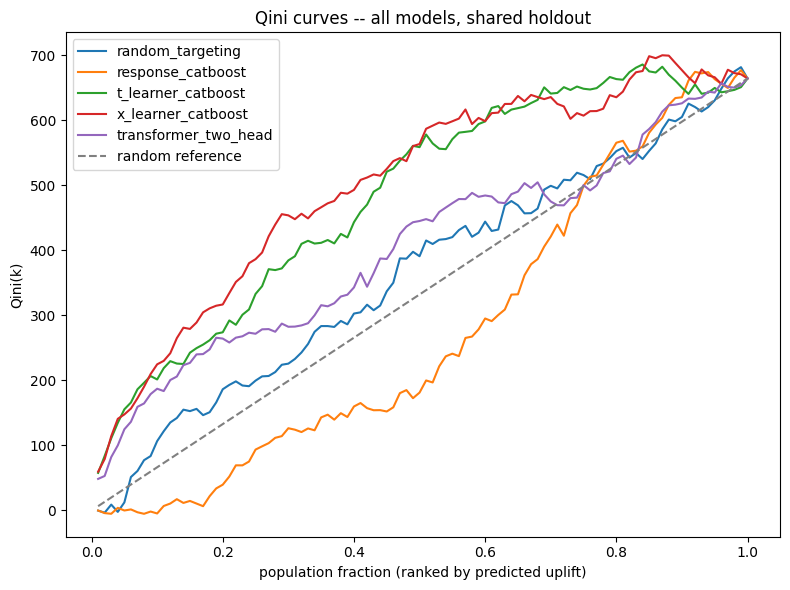

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, curve in qini_curves_data.items():
    ax.plot(curve["fractions"], curve["qini"], label=name)
ax.plot(curve["fractions"], curve["random"], linestyle="--", color="gray", label="random reference")
ax.set_xlabel("population fraction (ranked by predicted uplift)")
ax.set_ylabel("Qini(k)")
ax.set_title("Qini curves -- all models, shared holdout")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/qini_curves_all_models.png", dpi=120)
plt.show()


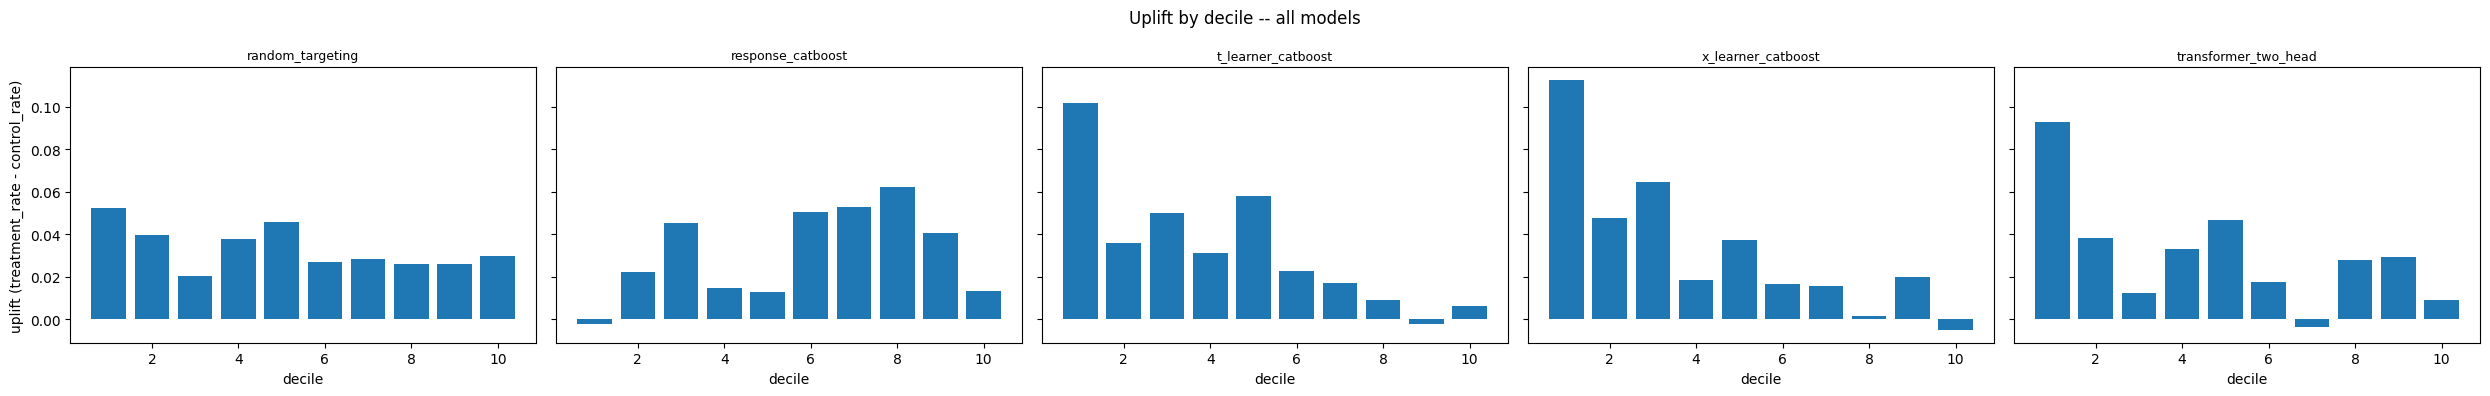

In [21]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4), sharey=True)
for ax, (name, deciles) in zip(axes, decile_tables.items()):
    d = pd.DataFrame(deciles)
    ax.bar(d["decile"], d["uplift"])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("decile")
axes[0].set_ylabel("uplift (treatment_rate - control_rate)")
plt.suptitle("Uplift by decile -- all models")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/uplift_by_decile_all_models.png", dpi=120)
plt.show()


## 15. Bootstrap confidence intervals

Already computed above (200-resample percentile bootstrap, see
`src/uplift_metrics.py::bootstrap_ci`) and included as `*_ci_low`/`*_ci_high`
columns in `metrics_df`. Displayed here explicitly as a forest-style plot
for Qini coefficient.


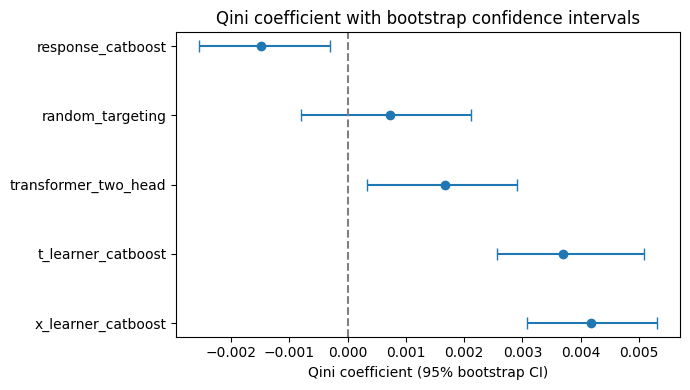

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(metrics_df))
ax.errorbar(
    metrics_df["qini"], y_pos,
    xerr=[metrics_df["qini"] - metrics_df["qini_ci_low"], metrics_df["qini_ci_high"] - metrics_df["qini"]],
    fmt="o", capsize=4,
)
ax.set_yticks(y_pos); ax.set_yticklabels(metrics_df["model"])
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Qini coefficient (95% bootstrap CI)")
ax.set_title("Qini coefficient with bootstrap confidence intervals")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/qini_bootstrap_ci.png", dpi=120)
plt.show()


## 16. Business evaluation

**All monetary figures below are an explicit, labeled SCENARIO** — a plausible
per-conversion margin and per-communication cost chosen for illustration —
**not measured X5 financial data and not a T-Bank result.** The purpose is
to show how an uplift ranking translates into a targeting decision under a
simple cost/benefit model, not to claim a real financial outcome.


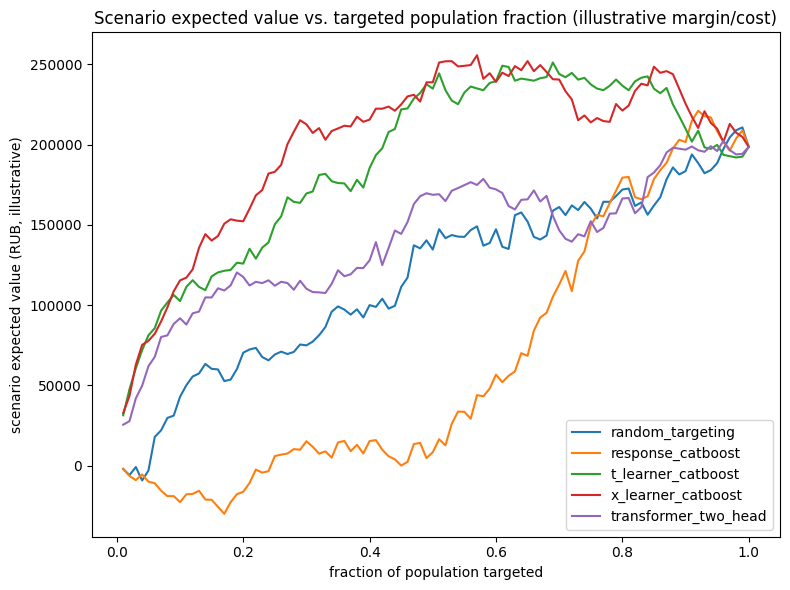

,model,best_fraction,best_expected_value
0,random_targeting,0.99,210670.147232
1,response_catboost,0.92,221001.977293
2,t_learner_catboost,0.69,251117.411732
3,x_learner_catboost,0.57,255618.247567
4,transformer_two_head,0.96,202353.641724


In [23]:
SCENARIO_MARGIN_PER_CONVERSION = 300.0   # illustrative RUB margin per incremental conversion -- a scenario, not real X5/T-Bank data
SCENARIO_COMMUNICATION_COST = 5.0        # illustrative RUB cost per SMS sent -- a scenario, not real X5/T-Bank data

def expected_value_curve(y_true, treatment, score, margin, cost, n_points=100):
    order = np.argsort(-score)
    y_sorted, t_sorted = y_true[order], treatment[order]
    n = len(y_true)
    fractions = np.linspace(1/n_points, 1.0, n_points)
    values = []
    for frac in fractions:
        k = int(frac * n)
        yk, tk = y_sorted[:k], t_sorted[:k]
        n_t, n_c = (tk == 1).sum(), (tk == 0).sum()
        rate_t = yk[tk == 1].mean() if n_t > 0 else 0.0
        rate_c = yk[tk == 0].mean() if n_c > 0 else 0.0
        incremental_rate = rate_t - rate_c
        incremental_conversions = incremental_rate * k
        ev = incremental_conversions * margin - k * cost
        values.append(ev)
    return fractions, np.array(values)

fig, ax = plt.subplots(figsize=(8, 6))
best_fracs = {}
for name, score in predictions.items():
    fracs, evs = expected_value_curve(y_holdout, t_holdout, score, SCENARIO_MARGIN_PER_CONVERSION, SCENARIO_COMMUNICATION_COST)
    ax.plot(fracs, evs, label=name)
    best_idx = np.argmax(evs)
    best_fracs[name] = {"best_fraction": float(fracs[best_idx]), "best_expected_value": float(evs[best_idx])}
ax.set_xlabel("fraction of population targeted"); ax.set_ylabel("scenario expected value (RUB, illustrative)")
ax.set_title("Scenario expected value vs. targeted population fraction (illustrative margin/cost)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/business_expected_value_curves.png", dpi=120)
plt.show()

business_df = pd.DataFrame(best_fracs).T.reset_index().rename(columns={"index": "model"})
business_df.to_csv(f"{ARTIFACTS_DIR}/business_evaluation.csv", index=False)
business_df


In [24]:
# Top-k% scenario table: incremental conversions and expected value at fixed 10/20/30% targeting
topk_rows = []
for name, score in predictions.items():
    order = np.argsort(-score)
    y_sorted, t_sorted = y_holdout[order], t_holdout[order]
    n = len(y_holdout)
    for k in [0.10, 0.20, 0.30]:
        kk = int(k * n)
        yk, tk = y_sorted[:kk], t_sorted[:kk]
        rate_t = yk[tk == 1].mean() if (tk == 1).sum() else 0.0
        rate_c = yk[tk == 0].mean() if (tk == 0).sum() else 0.0
        incr_rate = rate_t - rate_c
        incr_conversions = incr_rate * kk
        ev = incr_conversions * SCENARIO_MARGIN_PER_CONVERSION - kk * SCENARIO_COMMUNICATION_COST
        topk_rows.append({"model": name, "top_k": k, "incremental_conversions": incr_conversions, "scenario_expected_value": ev})
topk_df = pd.DataFrame(topk_rows)
topk_df.to_csv(f"{ARTIFACTS_DIR}/business_topk_scenarios.csv", index=False)
topk_df.pivot(index="model", columns="top_k", values="scenario_expected_value")


top_k,0.1,0.2,0.3
model,,,
random_targeting,42870.985918,70332.881510,74883.944134
response_catboost,-22758.025677,-16309.291969,15160.481609
t_learner_catboost,102454.279064,125823.270820,169510.665661
transformer_two_head,91748.682392,117507.374102,110168.673015
x_learner_catboost,115365.002009,152188.162313,212591.431630


In [25]:
# Sensitivity analysis: how does the best model's ranking-based decision change
# as the illustrative margin/cost assumptions vary?
best_model_name = metrics_df.iloc[0]["model"]
best_score = predictions[best_model_name]
sensitivity_rows = []
for margin in [150, 300, 600]:
    for cost in [2.5, 5.0, 10.0]:
        fracs, evs = expected_value_curve(y_holdout, t_holdout, best_score, margin, cost)
        best_idx = np.argmax(evs)
        sensitivity_rows.append({
            "margin": margin, "cost": cost,
            "best_fraction": float(fracs[best_idx]), "best_expected_value": float(evs[best_idx]),
        })
sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(f"{ARTIFACTS_DIR}/business_sensitivity_analysis.csv", index=False)
print(f"Sensitivity analysis for best model by holdout Qini: {best_model_name}")
sensitivity_df


Sensitivity analysis for best model by holdout Qini: x_learner_catboost


,margin,cost,best_fraction,best_expected_value
0,150,2.5,0.57,127809.123783
1,150,5.0,0.29,78570.063715
2,150,10.0,0.14,30081.194242
3,300,2.5,0.85,333528.726915
4,300,5.0,0.57,255618.247567
5,300,10.0,0.29,157140.127431
6,600,2.5,0.87,752555.973232
7,600,5.0,0.85,667057.453831
8,600,10.0,0.57,511236.495133


## 17. Online A/B-test design

**Offline Qini/AUUC are not proof of a real business effect.** They measure
ranking quality against a historical, already-randomized sample. Before any
uplift policy is deployed, it must be validated with a genuine, prospective
online experiment. Design sketch for validating the winning model
(highest-Qini model from Section 14) in production:

| Element | Design choice |
|---|---|
| Eligible population | All active loyalty clients due for a communication in the next campaign cycle |
| Randomization unit | Client (not household/session), matching the historical experiment's unit |
| Control policy | Current policy (e.g. communicate to everyone, or existing rule-based segment) |
| Uplift policy (treatment arm) | Communicate only to the top-k% by predicted uplift score, k chosen from Section 16's expected-value optimum |
| Primary metric | Incremental conversion rate attributable to the new targeting policy (difference-in-differences between the two arms' realized treatment effect) |
| Secondary metrics | Total communication volume/cost, unsubscribe/opt-out rate, downstream retention |
| Guardrails | Opt-out/complaint rate must not exceed current baseline by more than an agreed tolerance; no regression in overall revenue |
| MDE (minimum detectable effect) | Set from the holdout-observed incremental conversion rate at the chosen top-k% (Section 16), with a standard power calculation for a two-proportion test |
| Power | 80% (standard), 95% confidence |
| Duration | Sized to reach the required per-arm sample at the eligible population's typical weekly volume; long enough to cover at least one full weekly seasonality cycle |
| Analysis principle | Intention-to-treat (ITT): compare by assigned policy arm, not by whether the client actually opened/responded to the message, to avoid post-assignment selection bias |
| Success criterion | Statistically significant improvement in incremental conversions per communication sent, at non-negative guardrail metrics, translating to a positive scenario expected value at realized (not assumed) margin/cost |

This design is a template, not an executed experiment — no online A/B test
was run as part of this project (no production system access). It documents
what would need to happen before any of this project's offline numbers could
be treated as a real business result.


## 18. Comparison of all models


In [26]:
metrics_df


,model,auuc,auuc_ci_low,auuc_ci_high,qini,qini_ci_low,qini_ci_high,uplift_at_10,uplift_at_20,uplift_at_30,n_holdout
0,x_learner_catboost,0.012475,0.010364,0.015133,0.004176,0.003072,0.005311,0.113007,0.081384,0.075517,40011
1,t_learner_catboost,0.012000,0.009429,0.014914,0.003702,0.002564,0.005079,0.102010,0.070392,0.063856,40011
2,transformer_two_head,0.009971,0.007522,0.012747,0.001673,0.000339,0.002904,0.092855,0.065273,0.048085,40011
3,random_targeting,0.009030,0.006415,0.011945,0.000731,-0.000793,0.002115,0.053622,0.045962,0.037408,40011
4,response_catboost,0.006807,0.005064,0.009104,-0.001491,-0.002546,-0.000297,-0.002546,0.010936,0.021913,40011


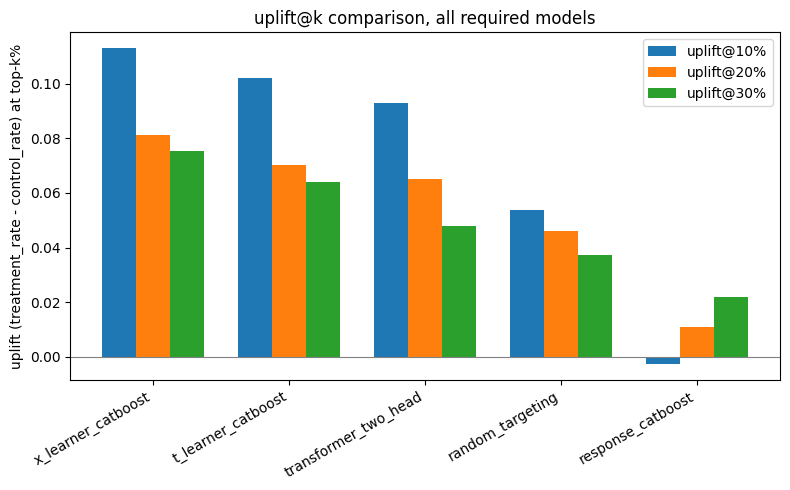

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics_df))
width = 0.25
ax.bar(x - width, metrics_df["uplift_at_10"], width, label="uplift@10%")
ax.bar(x, metrics_df["uplift_at_20"], width, label="uplift@20%")
ax.bar(x + width, metrics_df["uplift_at_30"], width, label="uplift@30%")
ax.set_xticks(x); ax.set_xticklabels(metrics_df["model"], rotation=30, ha="right")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("uplift (treatment_rate - control_rate) at top-k%")
ax.set_title("uplift@k comparison, all required models")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/uplift_at_k_comparison.png", dpi=120)
plt.show()


## 19. Limitations

- **Offline-only.** No online A/B test was executed; Section 17 is a design,
  not a result. Offline Qini/AUUC do not guarantee this ranking would produce
  the same incremental effect in a live, non-stationary environment.
- **Business figures are scenario-based**, not measured X5 or T-Bank
  financials (Section 16) — they illustrate the *method*, not a validated
  monetary outcome.
- **Single train/val/holdout split.** Metrics have bootstrap CIs (Section
  15) for sampling uncertainty within this split, but no repeated-split /
  cross-validation estimate of split-to-split variance was computed, given
  the project's time constraints.
- **Transformer compute budget.** Trained on CPU only, `hidden_size=64`,
  2 layers, up to 15 epochs with early stopping — a larger model, learned
  positional/time encodings, or longer sequences might change its ranking
  relative to the classical learners; the reported result reflects this
  specific, documented configuration, not an exhaustively tuned optimum.
- **Sequence truncation.** Clients with more than 50 pre-cutoff receipts
  (roughly the top decile) have their earliest history dropped; the
  Transformer only ever sees their most recent 50 shopping trips.
- **`age` data-quality cleaning** (clipping to [0,100], median imputation)
  is a judgment call; a small fraction of clients' true age is unknown after
  cleaning (flagged via `age_was_imputed`, not silently guessed).
- **No re-estimated propensity model** for the X-Learner: propensity is
  passed as the known constant 0.5. This is appropriate for this specific
  known-by-design 50/50 RCT, but the code would need an actual propensity
  model (`propensity=None`) to be reused on a non-randomized dataset.

## 20. Conclusions

See `reports/experiment_report.md` and `FINAL_REPORT.md` for the full
written conclusions, drafted from the `metrics_df` table produced by this
notebook (not from assumptions made before real numbers existed).
